About Dataset
This Data has been collected Majorly from Engineering students Testing the following data points from 1 to 5.

Kindly Rate your Sleep Quality
How many times a week do you suffer headaches
How would you rate you academic performance
how would you rate your study load?
How many times a week you practice extracurricular activities
How would you rate your stress levels?

https://www.kaggle.com/datasets/samyakb/student-stress-factors

In [1]:
import os
print(os.getcwd())

c:\Users\yenug\OneDrive\Desktop\python programs\pytorchcodes\gited


In [2]:
from pathlib import Path
path_for_data=Path("Student Stress Factors (2).csv")

In [3]:
print(path_for_data.exists())
print(path_for_data.name)

True
Student Stress Factors (2).csv


In [4]:
import pandas as pd
dataframe=pd.read_csv(path_for_data)
print(dataframe.shape)
print(f"\033[1;33m{"="*40}\033[0m")
print(dataframe.info())
print(f"\033[1;33m{"="*40}\033[0m")
print(dataframe.describe())

(520, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 6 columns):
 #   Column                                                            Non-Null Count  Dtype
---  ------                                                            --------------  -----
 0   Kindly Rate your Sleep Quality 😴                                  520 non-null    int64
 1   How many times a week do you suffer headaches 🤕?                  520 non-null    int64
 2   How would you rate you academic performance 👩‍🎓?                  520 non-null    int64
 3   how would you rate your study load?                               520 non-null    int64
 4   How many times a week you practice extracurricular activities 🎾?  520 non-null    int64
 5   How would you rate your stress levels?                            520 non-null    int64
dtypes: int64(6)
memory usage: 24.5 KB
None
       Kindly Rate your Sleep Quality 😴  \
count                        520.000000   
mean         

In [5]:
cols=dataframe.columns
print(cols)

Index(['Kindly Rate your Sleep Quality 😴',
       'How many times a week do you suffer headaches 🤕?',
       'How would you rate you academic performance 👩‍🎓?',
       'how would you rate your study load?',
       'How many times a week you practice extracurricular activities 🎾?',
       'How would you rate your stress levels?'],
      dtype='object')


In [6]:
dataframe.columns=["Sleep Quality","Head aches in week","rate academic performance","rate study load","extra activities in week","stress level"]

In [7]:
print(cols:=dataframe.columns)

Index(['Sleep Quality', 'Head aches in week', 'rate academic performance',
       'rate study load', 'extra activities in week', 'stress level'],
      dtype='object')


In [8]:
for i in cols:
        print(i)
        print(f"Max and Min and Min")
        print(dataframe[i].max())
        print(dataframe[i].min())
        print(dataframe[i].mean())
        print(f"\033[1;35m{"="*50}\033[0m")

Sleep Quality
Max and Min and Min
5
1
3.125
Head aches in week
Max and Min and Min
5
1
2.1826923076923075
rate academic performance
Max and Min and Min
5
1
3.326923076923077
rate study load
Max and Min and Min
5
1
2.75
extra activities in week
Max and Min and Min
5
1
2.6826923076923075
stress level
Max and Min and Min
5
1
2.875


In [9]:
#checking for any null values 
print(dataframe.isna().sum())


Sleep Quality                0
Head aches in week           0
rate academic performance    0
rate study load              0
extra activities in week     0
stress level                 0
dtype: int64


In [10]:
#checking for the duplicate rows
print(dataframe.duplicated().sum())

416


In [11]:
print(dataframe.drop_duplicates(inplace=True))

None


In [12]:
print(dataframe.shape)

(104, 6)


In [13]:
print(cols)

Index(['Sleep Quality', 'Head aches in week', 'rate academic performance',
       'rate study load', 'extra activities in week', 'stress level'],
      dtype='object')


In [14]:
y=dataframe["stress level"]
X=dataframe.drop("stress level",axis=1)
print(X.shape,y.shape)

(104, 5) (104,)


In [15]:
from sklearn.model_selection import train_test_split
train_x,test_x,train_y,test_y=train_test_split(X,y,random_state=42,train_size=0.75)
list_of_val=[train_x,train_y,test_x,test_y]
for i in list_of_val:
        print(i.shape)
print(f"\033[1;36m{"="*50}\033[0m")
for i in list_of_val:
        print(type(i))

(78, 5)
(78,)
(26, 5)
(26,)
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,HistGradientBoostingClassifier
from sklearn.svm import SVC


In [17]:
for i in cols:
        print(dataframe[i].dtype)
for i in cols:
        dataframe[i]=dataframe[i].astype('int16')
        print(dataframe[i].dtype)


int64
int64
int64
int64
int64
int64
int16
int16
int16
int16
int16
int16


In [18]:
train_x=train_x.to_numpy()
test_x=test_x.to_numpy()
train_y=train_y.to_numpy()
test_y=test_y.to_numpy()

In [19]:
print(type(test_x),type(train_x))



from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(train_x)
x_test_scaled=scaler.fit_transform(test_x)


<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [20]:
hgbc=HistGradientBoostingClassifier()
rfc=RandomForestClassifier()
svc=SVC()
dtc=DecisionTreeClassifier()
print(hgbc.get_params())
print(rfc.get_params())
print(svc.get_params())
print(dtc.get_params())

{'categorical_features': 'from_dtype', 'class_weight': None, 'early_stopping': 'auto', 'interaction_cst': None, 'l2_regularization': 0.0, 'learning_rate': 0.1, 'loss': 'log_loss', 'max_bins': 255, 'max_depth': None, 'max_features': 1.0, 'max_iter': 100, 'max_leaf_nodes': 31, 'min_samples_leaf': 20, 'monotonic_cst': None, 'n_iter_no_change': 10, 'random_state': None, 'scoring': 'loss', 'tol': 1e-07, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}
{'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr'

In [21]:
param_grid_hgbc={
        "l2_regularization":[0.0,0.5,1.0],
        "learning_rate":[0.1,0.01],
        "max_depth":[100,50,20]
}
param_grid_rfc={
        "max_leaf_nodes":[None,100,200],
        "min_samples_split":[2,3,4],
        
        "random_state":[21,42,2]
}
param_grid_svc={
        "C":[0.5,1],
        "degree":[1,2,3],
        "gamma":["scale","auto"],
        "kernel":["rbf","poly"]
}
param_grid_dtc={
        "max_features":[12,20],
        "random_state":[21,2,42]
}


In [22]:
from sklearn.model_selection import GridSearchCV
grid_search_svc=GridSearchCV(estimator=svc,param_grid=param_grid_svc,cv=5,scoring="accuracy")
grid_search_hgbc=GridSearchCV(estimator=hgbc,param_grid=param_grid_hgbc,cv=5,scoring="accuracy")
grid_search_rfc=GridSearchCV(estimator=rfc,param_grid=param_grid_rfc,cv=5,scoring="accuracy")
grid_search_dtc=GridSearchCV(estimator=dtc,param_grid=param_grid_dtc,cv=5,scoring="accuracy")


In [23]:
grid_search_dtc.fit(x_train_scaled,train_y)
grid_search_hgbc.fit(x_train_scaled,train_y)
grid_search_rfc.fit(x_train_scaled,train_y)
grid_search_svc.fit(x_train_scaled,train_y)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.5, 1], 'degree': [1, 2, 3],
                         'gamma': ['scale', 'auto'],
                         'kernel': ['rbf', 'poly']},
             scoring='accuracy')

In [24]:
print(grid_search_svc.best_score_)
print(grid_search_hgbc.best_score_)
print(grid_search_rfc.best_score_)
print(grid_search_dtc.best_score_)

0.3475
0.29416666666666663
0.3333333333333333
0.26749999999999996


In [25]:
svc_searched=grid_search_svc.best_estimator_
hgbc_searched=grid_search_hgbc.best_estimator_
rfc_searched=grid_search_rfc.best_estimator_
dtc_searched=grid_search_dtc.best_estimator_

In [26]:
from sklearn.metrics import accuracy_score
print(accuracy_score(svc_searched.predict(x_test_scaled),test_y))
print(accuracy_score(dtc_searched.predict(x_test_scaled),test_y))
print(accuracy_score(hgbc_searched.predict(x_test_scaled),test_y))
print(accuracy_score(rfc_searched.predict(x_test_scaled),test_y))

0.34615384615384615
0.3076923076923077
0.19230769230769232
0.34615384615384615


In [27]:
import pickle
pickle.dump(svc_searched,open("svm","wb"))

In [28]:
svc_load=pickle.load(open("svm","rb"))
svc_load.predict(x_test_scaled)


array([2, 2, 3, 3, 2, 3, 3, 3, 4, 3, 2, 3, 3, 3, 3, 5, 3, 2, 3, 1, 3, 3,
       3, 2, 2, 4], dtype=int64)

In [29]:
pickle.dump(dtc_searched,open("dtc","wb"))
pickle.dump(hgbc_searched,open("hgbc","wb"))
pickle.dump(rfc_searched,open("rfc","wb"))

In [30]:
import torch as t
from torch.utils.data import DataLoader,Dataset

In [31]:
#converting to torch datatype
x_train_tensor=t.from_numpy(x_train_scaled)
x_test_tensor=t.from_numpy(x_test_scaled)
y_train_tensor=t.from_numpy(train_y)
y_test_tensor=t.from_numpy(test_y)


In [32]:
print(type(x_train_tensor),type(x_test_tensor),type(y_train_tensor),type(y_test_tensor))

<class 'torch.Tensor'> <class 'torch.Tensor'> <class 'torch.Tensor'> <class 'torch.Tensor'>


In [33]:
print(x_train_tensor.shape)
print(x_test_tensor.shape)
print(y_train_tensor.shape)
print(y_test_tensor.shape)

torch.Size([78, 5])
torch.Size([26, 5])
torch.Size([78])
torch.Size([26])


In [34]:
class Datasetter(Dataset):
        def __init__(self,x,y):
                self.x=x
                self.y=y
        def __len__(self):
                return len(self.y)
        def __getitem__(self, index):
                return self.x[index],self.y[index]


In [35]:
train_dataset=Datasetter(x_train_tensor,y_train_tensor)
test_dataset=Datasetter(x_test_tensor,y_test_tensor)
print(train_dataset,test_dataset)

<__main__.Datasetter object at 0x00000235B09813D0> <__main__.Datasetter object at 0x00000235E92A9A00>


In [36]:
print(train_dataset.__len__())
print(test_dataset.__len__())

78
26


In [37]:
train_dataloader=DataLoader(
        dataset=train_dataset,
        batch_size=5,
        shuffle=True,
        pin_memory=False,
        drop_last=True,
        num_workers=0
)
test_dataloader=DataLoader(
        dataset=test_dataset,
        batch_size=5,
        shuffle=True,
        drop_last=True

)
print(train_dataloader.__len__())
print(test_dataloader.__len__())

15
5


In [38]:
for x,y in train_dataloader:
        print(x.shape)
        print(y.shape)
        break

torch.Size([5, 5])
torch.Size([5])


In [39]:
class Model(t.nn.Module):
        def __init__(self,inp_size,hid_size,out_size):
                super().__init__()
                self.Layer1=t.nn.Sequential(
                        t.nn.Linear(inp_size,hid_size),
                        t.nn.LeakyReLU(),
                        t.nn.Linear(hid_size,hid_size),
                        t.nn.LeakyReLU(),
                        t.nn.Linear(hid_size,out_size)

                )
        def forward(self,x:t.tensor):
                return self.Layer1(x)

                

In [40]:
Model_for_classification=Model(
        inp_size=5,
        hid_size=20,
        out_size=5
)
Model_for_classification

Model(
  (Layer1): Sequential(
    (0): Linear(in_features=5, out_features=20, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=20, out_features=20, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=20, out_features=5, bias=True)
  )
)

In [41]:
from torchinfo import summary
summary(Model_for_classification,input_size=(5,5),col_names=["num_params","trainable","input_size","output_size"])

Layer (type:depth-idx)                   Param #                   Trainable                 Input Shape               Output Shape
Model                                    --                        True                      [5, 5]                    [5, 5]
├─Sequential: 1-1                        --                        True                      [5, 5]                    [5, 5]
│    └─Linear: 2-1                       120                       True                      [5, 5]                    [5, 20]
│    └─LeakyReLU: 2-2                    --                        --                        [5, 20]                   [5, 20]
│    └─Linear: 2-3                       420                       True                      [5, 20]                   [5, 20]
│    └─LeakyReLU: 2-4                    --                        --                        [5, 20]                   [5, 20]
│    └─Linear: 2-5                       105                       True                      [5, 20]        

In [42]:
optimizer=t.optim.Adam(params=Model_for_classification.parameters(),lr=0.0001)
lossfn=t.nn.CrossEntropyLoss()

In [43]:
train_loss=[]
test_loss=[]
train_acc=[]
test_acc=[]
epochs=20
Model_for_classification.to(t.float32)
for epoch in range(epochs):
        train_l=0
        test_l=0
        train_a=0
        test_a=0
        Model_for_classification.train()
        for x,y in train_dataloader:
                x=x.to(t.float32)
                y=y.to(t.long)
                y=y-t.tensor(1)
                y_preds=Model_for_classification(x)
                loss=lossfn(y_preds,y)
                train_l+=loss.item()*5
                train_a+=((t.argmax(y_preds,dim=1))==y).sum().item()
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
        Model_for_classification.eval()
        with t.inference_mode():
                for x,y in test_dataloader:
                        x=x.to(t.float32)
                        y=y.to(t.long)
                        y=y-t.tensor(1)
                        y_preds=Model_for_classification(x)
                        loss=lossfn(y_preds,y)
                        test_l+=loss.item()*5
                        test_a+=((t.argmax(y_preds,dim=1))==y).sum().item()
        train_acc.append(train_a/len(train_dataloader.dataset))
        test_acc.append(test_a/len(test_dataloader.dataset))
        test_loss.append(test_l/len(test_dataloader.dataset))
        train_loss.append(train_l/len(train_dataloader.dataset))
        print(f" \033[1;35m Epoch:{epoch} \033[0m")
        print(f"{train_acc[epoch]} || {test_acc[epoch]} || {train_loss[epoch]} || {test_loss[epoch]}")
        print(f" \033[1;35m {"="*60} \033[0m")



  Epoch:0 
0.2692307692307692 || 0.07692307692307693 || 1.541558549954341 || 1.5682289692071767
  Epoch:1 
0.2692307692307692 || 0.07692307692307693 || 1.5393504653221521 || 1.5734387361086333
  Epoch:2 
0.24358974358974358 || 0.07692307692307693 || 1.542978095702636 || 1.573908581183507
  Epoch:3 
0.28205128205128205 || 0.07692307692307693 || 1.5358899801205366 || 1.5702030062675476
  Epoch:4 
0.2692307692307692 || 0.07692307692307693 || 1.5376466589096265 || 1.5802268569286053
  Epoch:5 
0.28205128205128205 || 0.07692307692307693 || 1.5400088062653174 || 1.573259555376493
  Epoch:6 
0.28205128205128205 || 0.07692307692307693 || 1.5339460663306408 || 1.5751227965721717
  Epoch:7 
0.28205128205128205 || 0.07692307692307693 || 1.5393219697169769 || 1.5762181694690998
  Epoch:8 
0.2948717948717949 || 0.07692307692307693 || 1.5326829827748811 || 1.5736569120333745
  Epoch:9 
0.28205128205128205 || 0.07692307692307693 || 1.5401027676386712 || 1.5771003869863658
  Epoch:10 
0.29487179487179

In [44]:
t.save(obj=Model_for_classification.state_dict(),f="torch.pth")

In [45]:
pickle.dump(Model_for_classification,file=open("torchpicky","wb"))

In [46]:
New_model=pickle.load(open("torchpicky","rb"))
print(New_model)

Model(
  (Layer1): Sequential(
    (0): Linear(in_features=5, out_features=20, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=20, out_features=20, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=20, out_features=5, bias=True)
  )
)


In [47]:
print(type(New_model))

<class '__main__.Model'>


In [48]:
import tensorflow as tf

In [49]:
x_train_tf=tf.Variable(x_train_scaled)
x_test_tf=tf.Variable(x_test_scaled)
y_train_tf=tf.Variable(train_y)
y_test_tf=tf.Variable(test_y)

In [51]:
print(x_train_tf.shape)
print(x_test_tf.shape)

(78, 5)
(26, 5)


In [52]:
train_dataset=tf.data.Dataset.from_tensor_slices((x_train_tf,y_train_tf))
test_dataset=tf.data.Dataset.from_tensor_slices((x_test_tf,y_test_tf))
print(train_dataset)
print(test_dataset)

<_TensorSliceDataset element_spec=(TensorSpec(shape=(5,), dtype=tf.float64, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
<_TensorSliceDataset element_spec=(TensorSpec(shape=(5,), dtype=tf.float64, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>


In [53]:
train_dataset=train_dataset.shuffle(buffer_size=train_dataset.cardinality())
test_dataset=test_dataset.shuffle(buffer_size=test_dataset.cardinality())


In [56]:
train_dataloader=train_dataset.batch(5,drop_remainder=True)
test_dataloader=test_dataset.batch(5,drop_remainder=True)

In [57]:
train_dataloader=train_dataloader.prefetch(tf.data.AUTOTUNE)
test_dataloader=test_dataloader.prefetch(tf.data.AUTOTUNE)

In [59]:
print(train_dataloader)
print(test_dataloader)

<_PrefetchDataset element_spec=(TensorSpec(shape=(5, 5), dtype=tf.float64, name=None), TensorSpec(shape=(5,), dtype=tf.int64, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(5, 5), dtype=tf.float64, name=None), TensorSpec(shape=(5,), dtype=tf.int64, name=None))>


In [60]:
print(train_dataloader.__len__())
print(test_dataloader.__len__())

tf.Tensor(15, shape=(), dtype=int64)
tf.Tensor(5, shape=(), dtype=int64)


In [65]:
Model_for_classification_tf=tf.keras.Sequential(
        [
                tf.keras.Input((5,)),
                tf.keras.layers.Dense(20,activation="relu"),
                tf.keras.layers.Dense(20,activation="leaky_relu"),
                tf.keras.layers.Dense(5)
        ]
)

In [73]:
Model_for_classification_tf.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
)

In [74]:
Model_for_classification_tf.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           105 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 645 (2.52 KB)

 Trainable params: 645 (2.52 KB)

 Non-trainable params: 0 (0.00 B)

In [84]:
Model_for_classification_tf.fit(x_train_tf,y_train_tf-1,verbose=1,epochs=20)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2144 - loss: 7.9477
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2237 - loss: 7.7099
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2168 - loss: 7.3632
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2066 - loss: 7.3194
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2365 - loss: 6.8709
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2688 - loss: 7.1493
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2802 - loss: 6.7883
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3062 - loss: 6.6696
Epoch 9/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3349 - loss: 6.1381
Epoch 10/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2988 - loss: 6.4493
Epoch 11/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2998 - loss: 6.1757
Epoch 12/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3023 - loss: 6.5082
Epoc

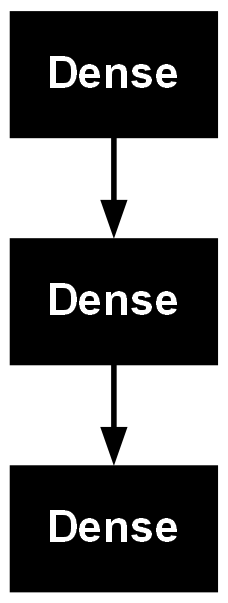

In [85]:
tf.keras.utils.plot_model(Model_for_classification_tf)

In [87]:
Model_for_classification_tf.evaluate(x_test_tf,y_test_tf-1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.1538 - loss: 6.2990


[6.2990241050720215, 0.1538461595773697]

In [88]:
pickle.dump(Model_for_classification_tf,open("tf_model","wb"))

In [89]:
l=pickle.load(open("tf_model","rb"))

In [90]:
l.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           105 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,937 (7.57 KB)

 Trainable params: 645 (2.52 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,292 (5.05 KB)